0 1.9435008764266968 0.316
10 0.5377673506736755 0.79
20 0.08283515274524689 0.791
30 0.01692558452486992 0.781
40 0.00637795589864254 0.772
50 0.0036865107249468565 0.774
60 0.0027149126399308443 0.775
70 0.0022362731397151947 0.778
80 0.001939103240147233 0.777
90 0.001723771565593779 0.776
Final Accuracy: 0.776


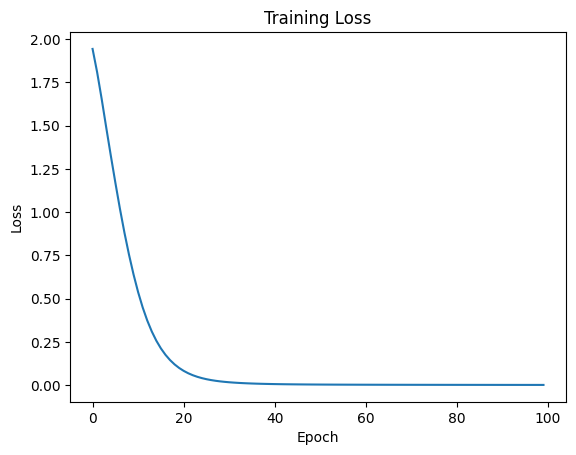

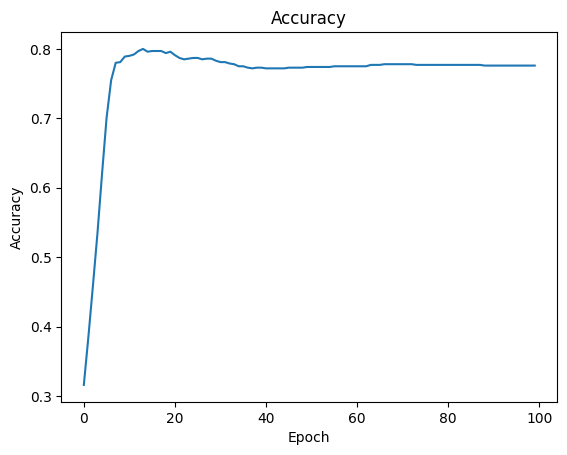

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv

dataset = Planetoid(root='/tmp/Cora', name='Cora')
data = dataset[0]

class GNN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(dataset.num_features, 16)
        self.conv2 = GCNConv(16, dataset.num_classes)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

model = GNN()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

losses = []
accuracies = []

for epoch in range(100):
    model.train()
    optimizer.zero_grad()
    out = model(data)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()

    model.eval()
    pred = model(data).argmax(dim=1)
    correct = (pred[data.test_mask] == data.y[data.test_mask]).sum()
    acc = int(correct) / int(data.test_mask.sum())

    losses.append(loss.item())
    accuracies.append(acc)

    if epoch % 10 == 0:
        print(epoch, loss.item(), acc)

print("Final Accuracy:", accuracies[-1])

plt.figure()
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.figure()
plt.plot(accuracies)
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()